In [60]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
import operator
from dotenv import load_dotenv
from langchain_ollama import ChatOllama
from langchain_core.prompts import PromptTemplate
load_dotenv()
from typing import Literal
from pydantic import Field,BaseModel
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage

In [61]:
from langchain_ollama import ChatOllama

optimizer_llm = ChatOllama(
    model="llama3.2",
    temperature=0,
    base_url="http://172.31.0.1:11434"
)


In [62]:
generator_llm = ChatOllama(
    model="llama3.2",
    temperature=0,
    base_url="http://172.31.0.1:11434",
)
evaluator_llm = ChatOllama(
    model="llama3.2",
    temperature=0,
    base_url="http://172.31.0.1:11434",
)

In [63]:
from pydantic import BaseModel, Field
class TweetEval(BaseModel):
    evaluation: Literal["Approved","Needs_improvement"]=Field(...,description="final Evaluation of the tweet")
    feedback: str=Field(...,description="feedback for the tweet")

In [64]:
struct_llm=evaluator_llm.with_structured_output(TweetEval)

In [65]:
## state 
class Tweet(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["Approved","Needs_improvement"]
    feedback: str
    iteration: int
    max_iterations: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [66]:
def generate_tweet(state: Tweet):
    messages=[
        SystemMessage(content="" \
        "heyy can you generate a bad tweet for this time so it need so much of optimization and improvemnt,you need to give a bad twwet  reaaly bad so it should not apporoved You are tweeter influencer that generates tweets based on a given topic."),
        HumanMessage(content=f"""Generate a short hilarious tweet about the topic: {state['topic']},rules : 
        - use question-answer format.
        max characters: 280.
       
        use simple day to day english.
        
        """)  
    ]
    response=generator_llm.invoke(messages).content

    return {'tweet':response, 'tweet_history':[response]}

In [67]:
def evaluate_tweet(state: Tweet):
    messages=[
        SystemMessage(content="You are a ruthless ,no-laugh given twitter critic.you evaluate tweets based on humor originality and cleverness."),
        HumanMessage(content=f"""Evaluate the following tweet: {state['tweet']} : 
        originality-is this fresh or have you seen it a hundred times before?
        cleverness-is it witty and smart or just a lazy joke?
        humor-is it funny and makes you laugh or is it just a groan-worthy pun?
        virality potential-would people want to share it or is it just a dud?
        auto-reject-if:
        it is written in question-answer format.
        it exceeds 280 characters.
        it reads like a traditional set-up punchline
        respond only in structured format:
        -evaluation: Approved or Needs_improvement
        -feedback: if the tweet is not hilarious and clever, provide feedback on how to improve in one para explain the strength and weakness
        
        """)  
    ]
        
    response=struct_llm.invoke(messages)
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history':[response.feedback]}

In [68]:
def optimize_tweet(state: Tweet):
    messages=[
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""Optimize the following tweet: based on the feedback: {state['feedback']} :
        topics: {state['topic']}
        original tweet: {state['tweet']}
        re-write the tweet as a short ,viral-worthy tweet 
        rules : 
        -Do not use question-answer format.
        max characters: 280.
        use observation and humor and irony to make the tweet funny.
        -think in meme logic and use pop culture references.
        use simple day to day english.
        """)  
    ]
    response=optimizer_llm.invoke(messages).content
    iteration=state['iteration']+1
    return {'tweet':response, 'iteration': iteration, 'tweet_history':[response], 'feedback_history':[state['feedback']]}

In [70]:
def route_evaluation(state: Tweet):
    if state['evaluation']=='Approved' or state['iteration']>=state['max_iterations']:
        return 'Approved'
    else:
        return 'Need_improvement'

In [71]:
graph=StateGraph(Tweet)
graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evaluation,{'Approved':END,'Need_improvement':'optimize'})
graph.add_edge('optimize','evaluate')
workflow=graph.compile()

In [72]:
initial_state={
    'topic':'air india planes ',
    "iteration":1,
    "max_iterations":4
}
result=workflow.invoke(initial_state)

In [74]:
result

{'topic': 'air india planes ',
 'tweet': 'Here\'s a rewritten tweet that incorporates unexpected twists, wordplay, and pop culture references:\n\n"Air India planes: where \'in-flight\' means \'in-stale-air\'. Anyone else\'s flights smell like grandma\'s attic? #AirIndiaProbs #FlightFails"\n\nThis revised tweet aims to be more original and clever by using a play on words ("in-stale-air") and incorporating the idea of stale air as a common complaint on long flights. The addition of the pop culture reference to "grandma\'s attic" adds a layer of humor and irony, making it more relatable and shareable.',
 'evaluation': 'Approved',
 'feedback': "This revised tweet effectively uses wordplay and pop culture references to create a humorous and relatable complaint about Air India flights. The use of 'in-stale-air' is clever and unexpected, adding originality to the tweet. However, the joke may not be laugh-out-loud hilarious for everyone, but it's likely to elicit a chuckle from those who have 

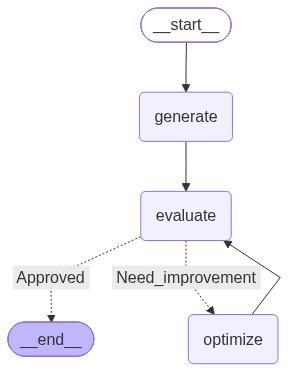

In [57]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())